# Sentiment Classification using RNN, LSTM, and Word2Vec Embeddings

## 6CS012 — Artificial Intelligence and Machine Learning  
Final Portfolio Project 2026

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Embedding,
    SimpleRNN,
    LSTM,
    Dropout,
    Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [ ]:
# !pip install numpy==1.23.5
# !pip install gensim
# !pip install jax==0.4.13
# !pip install -q --upgrade jax jaxlib

#Download NLTK Resources

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AI and Machine Learning - 6th Sem/Assessment/Text Classification/sarcastic_headlines.csv")

df.head()

,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


#Exploring dataset

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Info:")
print(df.info())

Dataset Shape: (28619, 2)

Column Names:
Index(['headline', 'is_sarcastic'], dtype='object')

Missing Values:
headline        0
is_sarcastic    0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   headline      28619 non-null  object
 1   is_sarcastic  28619 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 447.3+ KB
None


#Class Distribution Visualization

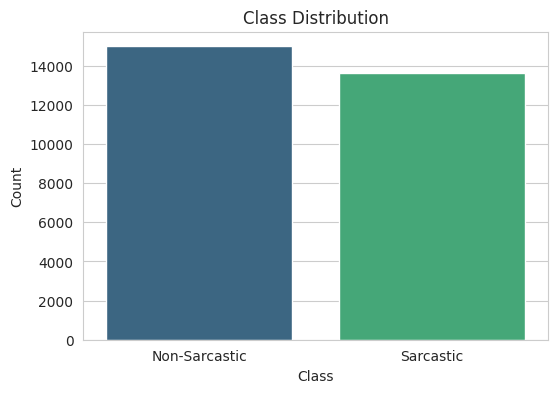

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x=df['is_sarcastic'],
    palette='viridis'
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.xticks(
    [0, 1],
    ['Non-Sarcastic', 'Sarcastic']
)

plt.show()

#Text Cleaning & Preprocessing

In [ ]:
for i in range(5):
    print(f"Headline {i+1}:")
    print(df['headline'][i])
    print("-" * 60)

Headline 1:
thirtysomething scientists unveil doomsday clock of hair loss
------------------------------------------------------------
Headline 2:
dem rep. totally nails why congress is falling short on gender, racial equality
------------------------------------------------------------
Headline 3:
eat your veggies: 9 deliciously different recipes
------------------------------------------------------------
Headline 4:
inclement weather prevents liar from getting to work
------------------------------------------------------------
Headline 5:
mother comes pretty close to using word 'streaming' correctly
------------------------------------------------------------


#Initialize Lemmatizer

In [ ]:
lemmatizer = WordNetLemmatizer()

# TEXT CLEANING FUNCTION

In [ ]:
!pip install contractions


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.0 MB/s eta 0:00:00


In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import contractions
import re

stop_words = set(stopwords.words('english'))

def improved_clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        '',
        text
    )

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtag symbol only
    text = re.sub(r'#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize text
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words back into sentence
    text = " ".join(words)

    return text

In [ ]:
import nltk
import contractions
nltk.download('punkt_tab')
df['improved_cleaned_headline'] = df['headline'].apply(
    improved_clean_text
)

print("Improved Text Cleaning Completed!")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Improved Text Cleaning Completed!


In [ ]:
for i in range(5):

    print(f"\nOriginal:")
    print(df['headline'][i])

    print(f"\nImproved Cleaning:")
    print(df['improved_cleaned_headline'][i])

    print("=" * 80)


Original:
thirtysomething scientists unveil doomsday clock of hair loss

Improved Cleaning:
thirtysomething scientists unveil doomsday clock hair loss

Original:
dem rep. totally nails why congress is falling short on gender, racial equality

Improved Cleaning:
dem rep totally nails congress falling short gender racial equality

Original:
eat your veggies: 9 deliciously different recipes

Improved Cleaning:
eat veggies deliciously different recipes

Original:
inclement weather prevents liar from getting to work

Improved Cleaning:
inclement weather prevents liar getting work

Original:
mother comes pretty close to using word 'streaming' correctly

Improved Cleaning:
mother comes pretty close using word streaming correctly


In [ ]:
empty_rows = df[df['improved_cleaned_headline'].str.strip() == ""]
print("Empty Rows After Cleaning:", len(empty_rows))

Empty Rows After Cleaning: 2


In [ ]:
text_lengths = df['improved_cleaned_headline'].apply(
    lambda x: len(x.split())
)

print("Maximum Length :", text_lengths.max())
print("Minimum Length :", text_lengths.min())
print("Average Length :", round(text_lengths.mean(), 2))

Maximum Length : 106
Minimum Length : 0
Average Length : 7.07


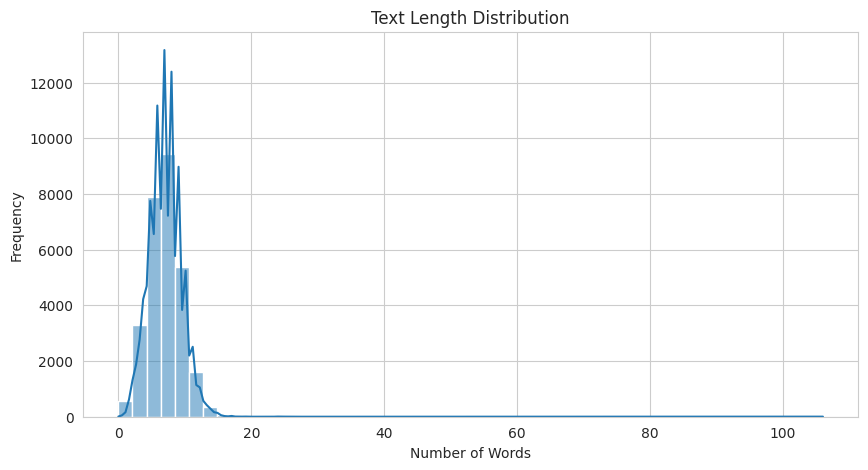

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    text_lengths,
    bins=50,
    kde=True
)

plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [ ]:
max_length = int(
    np.percentile(text_lengths, 95)
)

print("95th Percentile Sequence Length:", max_length)

95th Percentile Sequence Length: 11


#Step 3 — Word Visualization & Exploratory Text Analysis

#Generate The Word Cloud

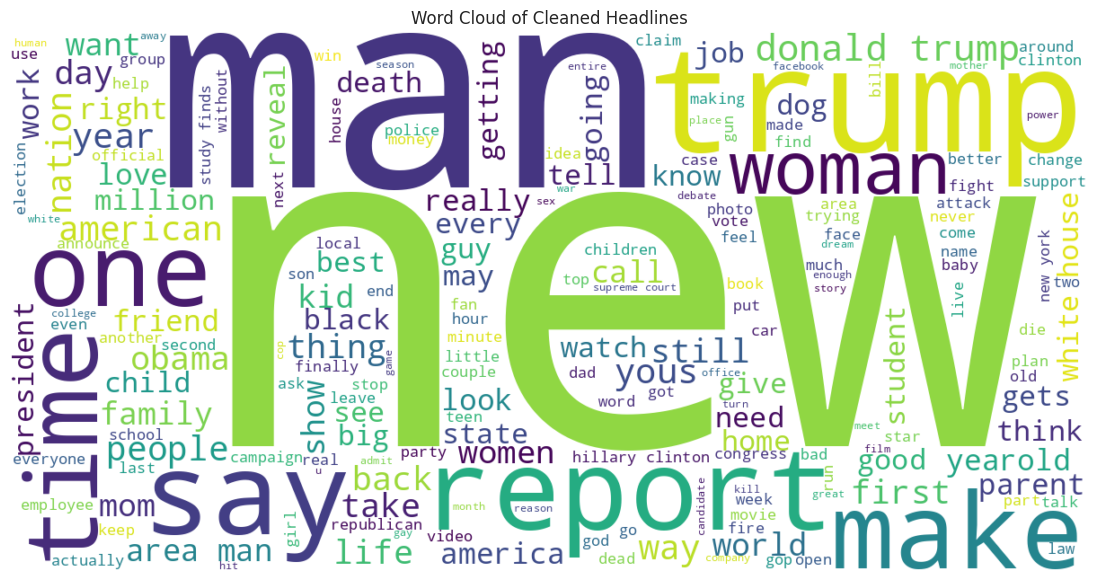

In [ ]:
all_words = " ".join(df['improved_cleaned_headline'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis'
).generate(all_words)

# Plot WordCloud
plt.figure(figsize=(14, 7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Word Cloud of Cleaned Headlines")

plt.show()

In [ ]:
from collections import Counter

# Combine all words
all_tokens = " ".join(
    df['improved_cleaned_headline']
).split()

# Count frequencies
word_counts = Counter(all_tokens)

# Top 20 words
top_words = word_counts.most_common(20)

# Convert to DataFrame
top_words_df = pd.DataFrame(
    top_words,
    columns=['Word', 'Frequency']
)

top_words_df

,Word,Frequency
0,new,1677
1,trump,1389
2,man,1373
3,report,605
4,one,555
5,woman,505
6,area,494
7,day,493
8,says,485
9,donald,475


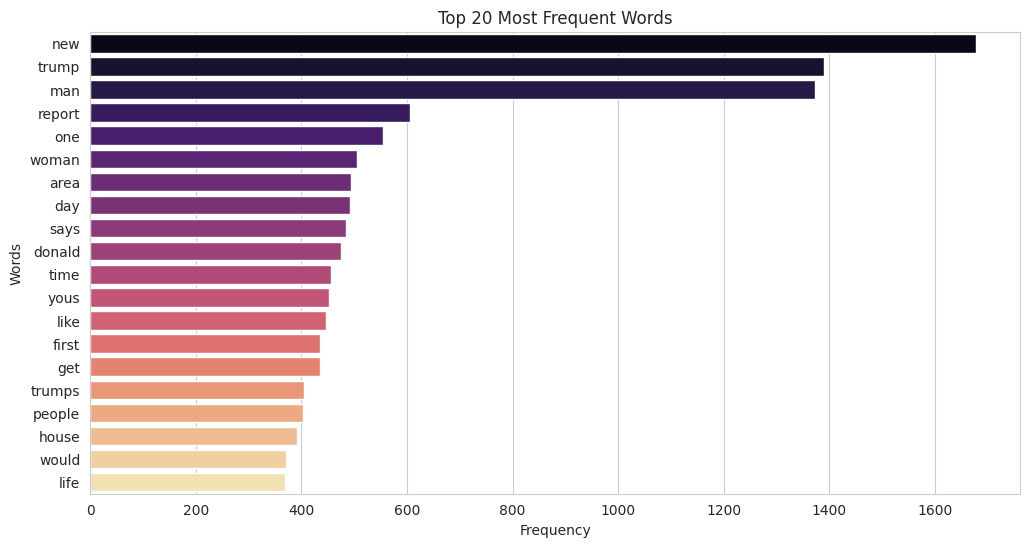

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x='Frequency',
    y='Word',
    data=top_words_df,
    palette='magma'
)

plt.title("Top 20 Most Frequent Words")

plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()


# SPLIT DATA BY CLASS



In [ ]:
sarcastic_text = df[
    df['is_sarcastic'] == 1
]['improved_cleaned_headline']

non_sarcastic_text = df[
    df['is_sarcastic'] == 0
]['improved_cleaned_headline']

# SARCASTIC WORD CLOUD

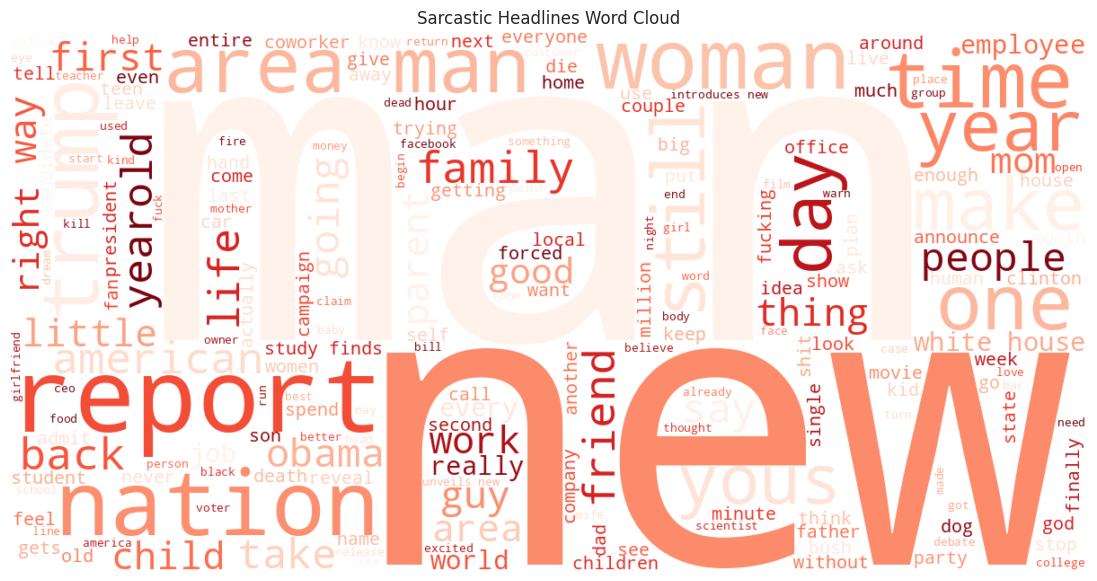

In [ ]:
sarcastic_words = " ".join(sarcastic_text)

sarcastic_cloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='Reds'
).generate(sarcastic_words)

plt.figure(figsize=(14, 7))

plt.imshow(sarcastic_cloud, interpolation='bilinear')

plt.axis('off')

plt.title("Sarcastic Headlines Word Cloud")

plt.show()

#WordCloud for Non-Sarcastic Headlines

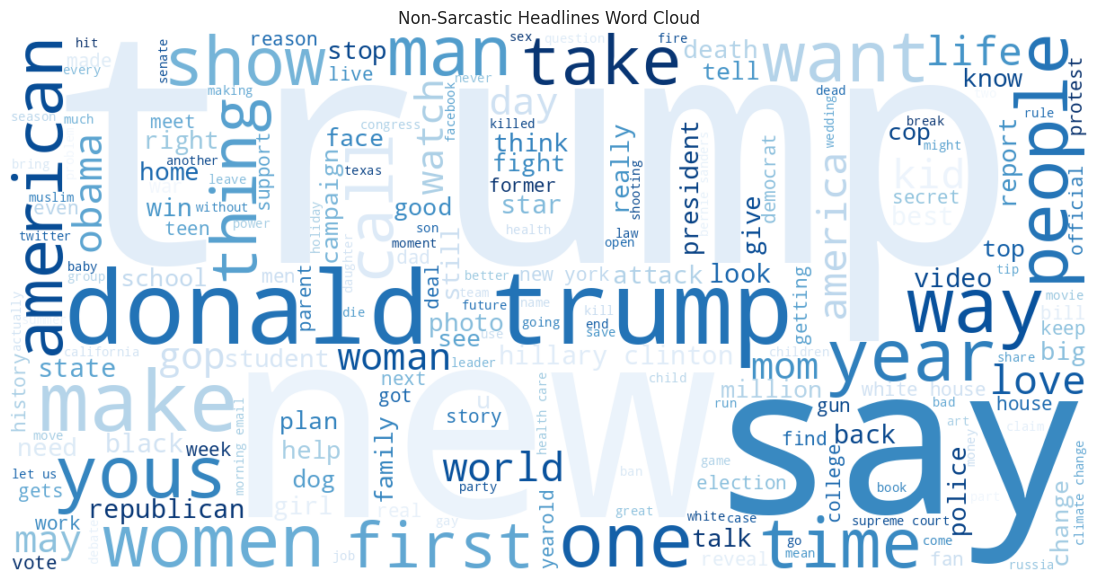

In [ ]:
non_sarcastic_words = " ".join(non_sarcastic_text)

non_sarcastic_cloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='Blues'
).generate(non_sarcastic_words)

plt.figure(figsize=(14, 7))

plt.imshow(non_sarcastic_cloud, interpolation='bilinear')

plt.axis('off')

plt.title("Non-Sarcastic Headlines Word Cloud")

plt.show()

#Step 4 — Tokenization & Sequence Padding

# TRAIN TEST SPLIT

In [ ]:
X = df['improved_cleaned_headline']
y = df['is_sarcastic']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 22895
Testing Samples  : 5724


#Tokenization

In [ ]:
vocab_size = 15000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

print("Updated Tokenizer Created!")

Updated Tokenizer Created!


#Vocabulary Analysis

In [ ]:
word_index = tokenizer.word_index

print("Total Unique Words:", len(word_index))

print("\nTop 20 Words:")
for word, index in list(word_index.items())[:20]:
    print(f"{word} --> {index}")

Total Unique Words: 25748

Top 20 Words:
<OOV> --> 1
new --> 2
trump --> 3
man --> 4
report --> 5
one --> 6
area --> 7
woman --> 8
says --> 9
day --> 10
time --> 11
donald --> 12
like --> 13
yous --> 14
get --> 15
first --> 16
trumps --> 17
people --> 18
house --> 19
life --> 20


#Convert Text to Sequences

In [ ]:
X_train_sequences = tokenizer.texts_to_sequences(X_train)

X_test_sequences = tokenizer.texts_to_sequences(X_test)

print("Updated Sequences Created!")

Updated Sequences Created!


#Inspect Sample Sequences

In [ ]:
print("Original Text:\n")
print(X_train.iloc[0])

print("\nInteger Sequence:\n")
print(X_train_sequences[0])

Original Text:

paramount executive snaps script begins studio logo fading establishing shot actual mountain

Integer Sequence:

[4485, 847, 4486, 2974, 541, 1639, 3971, 7289, 9394, 409, 2345, 2733]


#Applying The Padding

In [ ]:
max_length = 30

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Updated Padding Applied!")

Updated Padding Applied!


#Inspect Padding

In [ ]:
print("Original Sequence:")
print(X_train_sequences[0])

print("\nPadded Sequence:")
print(X_train_padded[0])

print("\nSequence Length:")
print(len(X_train_padded[0]))

Original Sequence:
[4485, 847, 4486, 2974, 541, 1639, 3971, 7289, 9394, 409, 2345, 2733]

Padded Sequence:
[4485  847 4486 2974  541 1639 3971 7289 9394  409 2345 2733    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]

Sequence Length:
30


#Convert Labels to NumPy Arrays

In [ ]:


y_train = np.array(y_train)
y_test = np.array(y_test)

print("Labels Converted Successfully!")

Labels Converted Successfully!


In [ ]:
print("X_train Shape:", X_train_padded.shape)
print("X_test Shape :", X_test_padded.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (22895, 30)
X_test Shape : (5724, 30)
y_train Shape: (22895,)
y_test Shape : (5724,)


#Step 5 — Model 1: Simple RNN with Trainable Embedding

In [ ]:
from tensorflow.keras.layers import Input

embedding_dim = 128

simple_rnn_model = Sequential([

    # Input Layer
    Input(shape=(max_length,)),

    # Embedding Layer
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),

    # Simple RNN Layer
    SimpleRNN(
        64,
        return_sequences=False
    ),

    # Dropout Layer
    Dropout(0.5),

    # Dense Layer
    Dense(32, activation='relu'),

    # Output Layer
    Dense(1, activation='sigmoid')
])

simple_rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 128)        │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,934,465 (7.38 MB)

 Trainable params: 1,934,465 (7.38 MB)

 Non-trainable params: 0 (0.00 B)

#Compile Model

In [ ]:
simple_rnn_model.compile(

    loss='binary_crossentropy',

    optimizer='adam',

    metrics=['accuracy']
)

print("Simple RNN Model Compiled Successfully!")

Simple RNN Model Compiled Successfully!


# CALLBACKS

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

print("Callbacks Created Successfully!")

Callbacks Created Successfully!


#Training Model

In [ ]:
history_rnn = simple_rnn_model.fit(

    X_train_padded,
    y_train,

    validation_split=0.2,

    epochs=20,

    batch_size=32,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.7243 - loss: 0.5465 - val_accuracy: 0.7615 - val_loss: 0.5016 - learning_rate: 0.0010
Epoch 2/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.8865 - loss: 0.2872 - val_accuracy: 0.7897 - val_loss: 0.5059 - learning_rate: 0.0010
Epoch 3/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9555 - loss: 0.1275
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
573/573 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.9488 - loss: 0.1419 - val_accuracy: 0.7849 - val_loss: 0.6506 - learning_rate: 0.0010
Epoch 4/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.9838 - loss: 0.0479 - val_accuracy: 0.7794 - val_loss: 0.8296 - learning_rate: 5.0000e-04
Epoch 5/20
572/573 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9953 - loss: 0.0175
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
573/573 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.9959 - l

#Plot Accuracy Curves

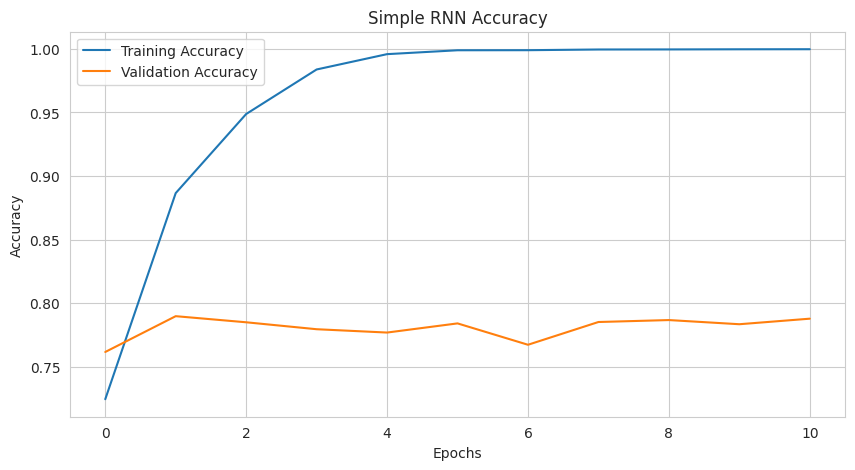

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_rnn.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_rnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Simple RNN Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

#Plot Loss Curves

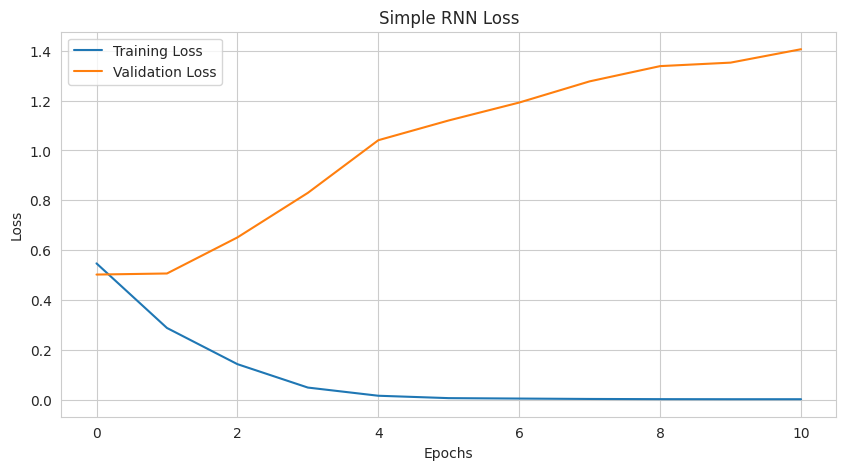

In [44]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_rnn.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_rnn.history['val_loss'],
    label='Validation Loss'
)

plt.title("Simple RNN Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [45]:
# Predict probabilities
y_pred_prob = simple_rnn_model.predict(X_test_padded)

# Convert probabilities to binary predictions
y_pred = (y_pred_prob > 0.5).astype(int)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", round(accuracy, 4))

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Test Accuracy: 0.7633


In [46]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.79      0.74      0.77      2997
           1       0.73      0.79      0.76      2727

    accuracy                           0.76      5724
   macro avg       0.76      0.76      0.76      5724
weighted avg       0.77      0.76      0.76      5724



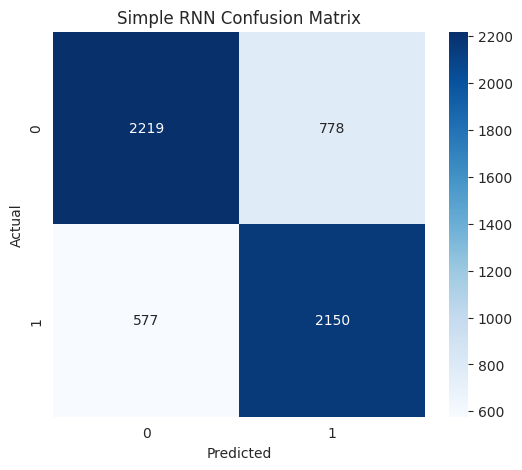

In [47]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Simple RNN Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#Step 7 — Model 2: LSTM with Trainable Embedding

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

early_stopping = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True,

    verbose=1
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=1,

    verbose=1
)

print("Improved Callbacks Ready!")

Improved Callbacks Ready!


In [ ]:
from tensorflow.keras.layers import BatchNormalization

improved_lstm_model = Sequential([

    # Input Layer
    Input(shape=(max_length,)),

    # Embedding Layer
    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    # Bidirectional LSTM
    LSTM(
        128,
        dropout=0.3,
        recurrent_dropout=0.3
    ),

    # Batch Normalization
    BatchNormalization(),

    # Dense Layer
    Dense(64, activation='relu'),

    # Dropout
    Dropout(0.5),

    # Output Layer
    Dense(1, activation='sigmoid')
])

# Model Summary
improved_lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 30, 128)        │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,060,417 (7.86 MB)

 Trainable params: 2,060,161 (7.86 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
improved_lstm_model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']
)

print("Improved LSTM Compiled Successfully!")

Improved LSTM Compiled Successfully!


In [ ]:
history_improved_lstm = improved_lstm_model.fit(

    X_train_padded,
    y_train,

    validation_split=0.2,

    epochs=15,

    batch_size=32,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 79s 129ms/step - accuracy: 0.6531 - loss: 0.5926 - val_accuracy: 0.8163 - val_loss: 0.3961 - learning_rate: 0.0010
Epoch 2/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 76s 119ms/step - accuracy: 0.8709 - loss: 0.3357 - val_accuracy: 0.8419 - val_loss: 0.3664 - learning_rate: 0.0010
Epoch 3/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9237 - loss: 0.2146
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
573/573 ━━━━━━━━━━━━━━━━━━━━ 70s 123ms/step - accuracy: 0.9194 - loss: 0.2245 - val_accuracy: 0.8504 - val_loss: 0.3861 - learning_rate: 0.0010
Epoch 4/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9587 - loss: 0.1397
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
573/573 ━━━━━━━━━━━━━━━━━━━━ 67s 117ms/step - accuracy: 0.9547 - loss: 0.1438 - val_accuracy: 0.8456 - val_loss: 0.5190 - learning_rate: 5.0000e-04
Epoch 5/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.97

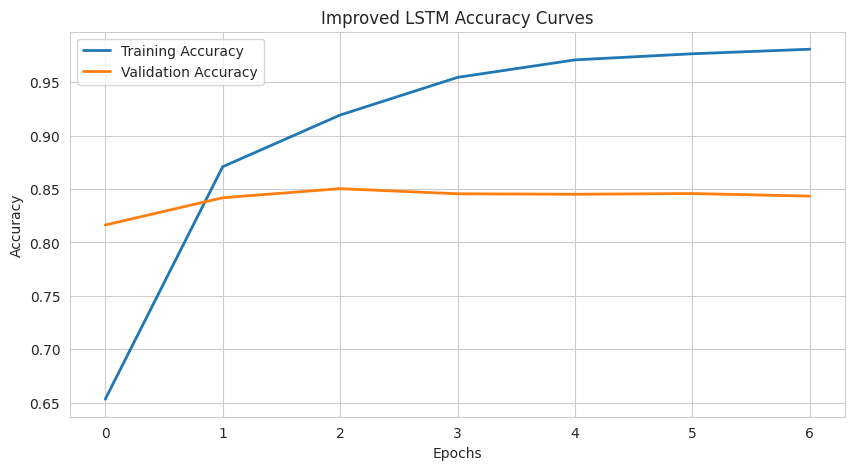

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_improved_lstm.history['accuracy'],
    label='Training Accuracy',
    linewidth=2
)

plt.plot(
    history_improved_lstm.history['val_accuracy'],
    label='Validation Accuracy',
    linewidth=2
)

plt.title("Improved LSTM Accuracy Curves")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

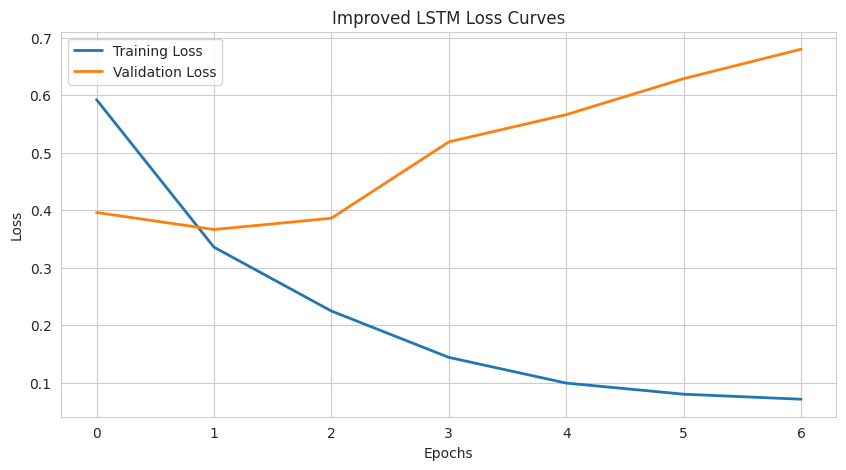

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_improved_lstm.history['loss'],
    label='Training Loss',
    linewidth=2
)

plt.plot(
    history_improved_lstm.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

plt.title("Improved LSTM Loss Curves")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Predict probabilities
y_pred_prob_improved = improved_lstm_model.predict(
    X_test_padded
)

# Convert probabilities to binary predictions
y_pred_improved = (
    y_pred_prob_improved > 0.5
).astype(int)

# Accuracy
improved_accuracy = accuracy_score(
    y_test,
    y_pred_improved
)

print(
    "Improved LSTM Test Accuracy:",
    round(improved_accuracy, 4)
)

179/179 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step
Improved LSTM Test Accuracy: 0.8435


In [ ]:
print(
    classification_report(
        y_test,
        y_pred_improved
    )
)

              precision    recall  f1-score   support

           0       0.90      0.79      0.84      2997
           1       0.80      0.90      0.85      2727

    accuracy                           0.84      5724
   macro avg       0.85      0.85      0.84      5724
weighted avg       0.85      0.84      0.84      5724



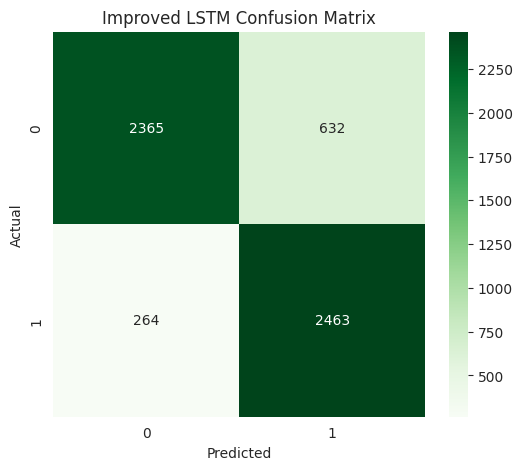

In [ ]:
cm_improved = confusion_matrix(
    y_test,
    y_pred_improved
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_improved,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Improved LSTM Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
!pip install numpy==1.23.5
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 51.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.9 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api

print("Gensim Imported Successfully!")

Gensim Imported Successfully!


In [ ]:
embedding_model = api.load(
    'glove-twitter-100'
)

print("Pretrained Embeddings Loaded!")

[==================================================] 100.0% 387.1/387.1MB downloaded
Pretrained Embeddings Loaded!


In [ ]:
embedding_dim = 100

word_index = tokenizer.word_index

embedding_matrix = np.zeros(
    (vocab_size, embedding_dim)
)

for word, i in word_index.items():

    if i < vocab_size:

        if word in embedding_model:

            embedding_matrix[i] = embedding_model[word]

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Embedding,
    LSTM,
    Dropout,
    Bidirectional,
    Input,
    BatchNormalization,
    SpatialDropout1D
)


word2vec_model = Sequential([

    # Input Layer
    Input(shape=(max_length,)),

    # Pretrained Embedding Layer
    Embedding(

        input_dim=vocab_size,

        output_dim=embedding_dim,

        weights=[embedding_matrix],

        input_length=max_length,

        trainable=False
    ),

    # Spatial Dropout
     SpatialDropout1D(0.3),


    LSTM(
        64,
        dropout=0.3,
        recurrent_dropout=0.3
    ),

    # Batch Normalization
    BatchNormalization(),

    # Dense Layer
    Dense(32, activation='relu'),

    # Dropout
    Dropout(0.5),

    # Output Layer
    Dense(1, activation='sigmoid')
])

word2vec_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 30, 100)        │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 30, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,544,609 (5.89 MB)

 Trainable params: 44,481 (173.75 KB)

 Non-trainable params: 1,500,128 (5.72 MB)

In [ ]:
word2vec_model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']
)

print("Word2Vec Model Compiled!")

Word2Vec Model Compiled!


In [ ]:
history_word2vec = word2vec_model.fit(

    X_train_padded,
    y_train,

    validation_split=0.2,

    epochs=10,

    batch_size=32,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.6088 - loss: 0.6594 - val_accuracy: 0.7408 - val_loss: 0.6029 - learning_rate: 0.0010
Epoch 2/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 26s 46ms/step - accuracy: 0.6885 - loss: 0.5977 - val_accuracy: 0.7598 - val_loss: 0.5012 - learning_rate: 0.0010
Epoch 3/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.7246 - loss: 0.5554 - val_accuracy: 0.7672 - val_loss: 0.4894 - learning_rate: 0.0010
Epoch 4/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 42s 44ms/step - accuracy: 0.7540 - loss: 0.5161 - val_accuracy: 0.8043 - val_loss: 0.4113 - learning_rate: 0.0010
Epoch 5/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.7729 - loss: 0.4880 - val_accuracy: 0.8205 - val_loss: 0.4054 - learning_rate: 0.0010
Epoch 6/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.7792 - loss: 0.4744 - val_accuracy: 0.8259 - val_loss: 0.3831 - learning_rate: 0.0010
Epoch 7/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - accuracy: 0.7918 - l

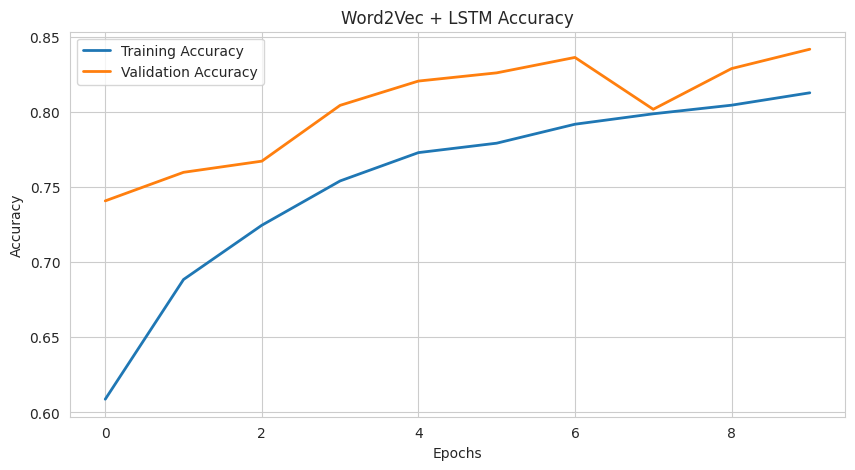

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_word2vec.history['accuracy'],
    label='Training Accuracy',
    linewidth=2
)

plt.plot(
    history_word2vec.history['val_accuracy'],
    label='Validation Accuracy',
    linewidth=2
)

plt.title("Word2Vec + LSTM Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

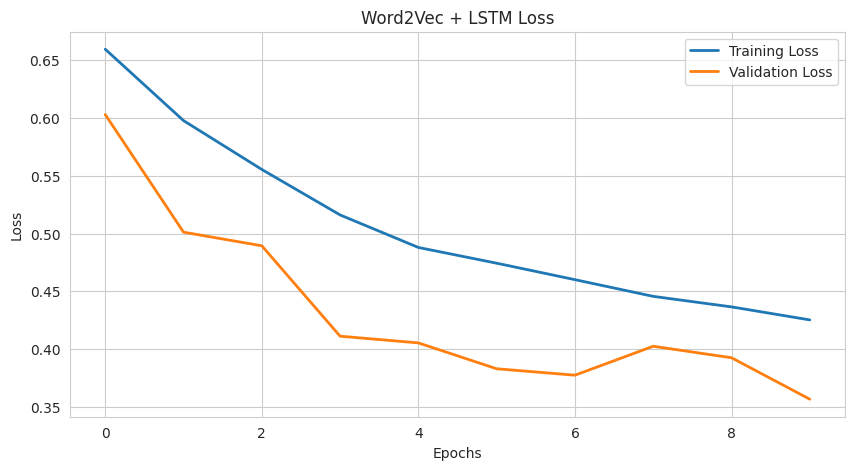

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_word2vec.history['loss'],
    label='Training Loss',
    linewidth=2
)

plt.plot(
    history_word2vec.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

plt.title("Word2Vec + LSTM Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Predict probabilities
y_pred_prob_word2vec = word2vec_model.predict(
    X_test_padded
)

# Convert probabilities to binary predictions
y_pred_word2vec = (
    y_pred_prob_word2vec > 0.5
).astype(int)

# Accuracy
word2vec_accuracy = accuracy_score(
    y_test,
    y_pred_word2vec
)

print(
    "Word2Vec + LSTM Test Accuracy:",
    round(word2vec_accuracy, 4)
)

179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
Word2Vec + LSTM Test Accuracy: 0.8512


In [ ]:
print(
    classification_report(
        y_test,
        y_pred_word2vec
    )
)

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      2997
           1       0.84      0.84      0.84      2727

    accuracy                           0.85      5724
   macro avg       0.85      0.85      0.85      5724
weighted avg       0.85      0.85      0.85      5724



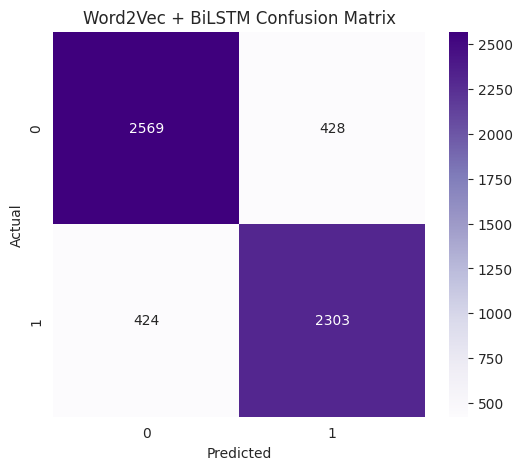

In [ ]:
cm_word2vec = confusion_matrix(
    y_test,
    y_pred_word2vec
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_word2vec,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("Word2Vec + BiLSTM Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Comparison of NLP models

In [ ]:
comparison_df = pd.DataFrame({

    'Model': [
        'Simple RNN',
        'Improved BiLSTM',
        'Word2Vec + BiLSTM'
    ],

    'Test Accuracy': [
        accuracy,
        improved_accuracy,
        word2vec_accuracy
    ]
})

comparison_df

,Model,Test Accuracy
0,Simple RNN,0.816562
1,Improved BiLSTM,0.843466
2,Word2Vec + BiLSTM,0.851153


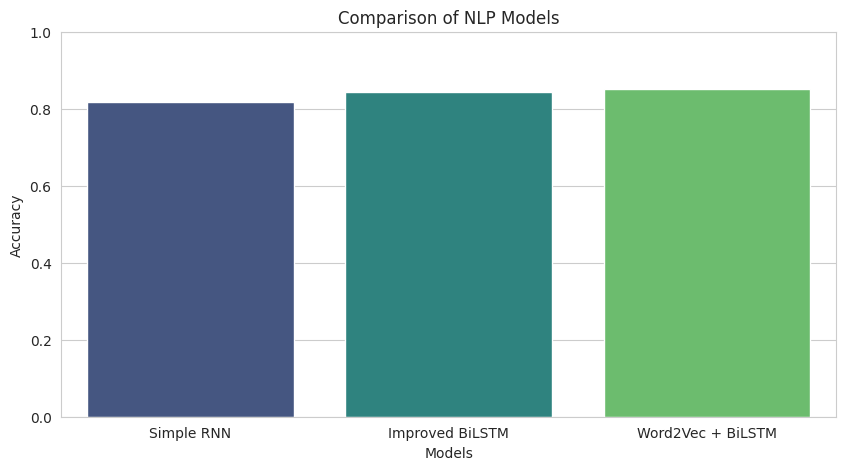

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x='Model',
    y='Test Accuracy',
    data=comparison_df,
    palette='viridis'
)

plt.title("Comparison of NLP Models")

plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()

# Misclassified Examples

In [ ]:
misclassified_indices = np.where(
    y_test != y_pred_word2vec.flatten()
)[0]

print(
    "Total Misclassified Examples:",
    len(misclassified_indices)
)

Total Misclassified Examples: 852


In [ ]:
for i in misclassified_indices[:5]:

    print("\nHeadline:")
    print(X_test.iloc[i])

    print("\nActual Label:")
    print(
        "Sarcastic"
        if y_test[i] == 1
        else "Not Sarcastic"
    )

    print("\nPredicted Label:")
    print(
        "Sarcastic"
        if y_pred_word2vec[i] == 1
        else "Not Sarcastic"
    )

    print("=" * 80)


Headline:
tom gilbert, actor who portrays tv's regis philbin, to leave 'regis & kelly' show

Actual Label:
Sarcastic

Predicted Label:
Not Sarcastic

Headline:
huckabee backs denying abortion to -year-old raped by stepfather

Actual Label:
Not Sarcastic

Predicted Label:
Sarcastic

Headline:
kate middleton suffering from morning sickness

Actual Label:
Sarcastic

Predicted Label:
Not Sarcastic

Headline:
you.s. asks africa not to cash aid checks until after tax day

Actual Label:
Sarcastic

Predicted Label:
Not Sarcastic

Headline:
museum of television and radio acquires rare 'caroline in the city' episode

Actual Label:
Sarcastic

Predicted Label:
Not Sarcastic


# GUI

In [ ]:
def predict_sarcasm(text):
    try:
        if text.strip() == "":
            return {"Not Sarcastic": 0.0, "Sarcastic": 0.0}

        # Clean text
        cleaned_text = improved_clean_text(text)

        # Convert to sequence
        sequence = tokenizer.texts_to_sequences([cleaned_text])

        # Pad sequence
        padded_sequence = pad_sequences(
            sequence,
            maxlen=max_length,
            padding='post',
            truncating='post'
        )

        # Predict
        prediction = word2vec_model.predict(padded_sequence, verbose=0)

        # Convert prediction safely
        sarcasm_prob = float(prediction[0][0])
        non_sarcasm_prob = float(1 - sarcasm_prob)

        return {
            "Not Sarcastic": non_sarcasm_prob,
            "Sarcastic": sarcasm_prob
        }

    except Exception as e:
        return {"Error": str(e)}

In [ ]:
import gradio as gr

interface = gr.Interface(

    fn=predict_sarcasm,

    inputs=gr.Textbox(
        lines=3,
        placeholder="Enter text here..."
    ),

    outputs=gr.Label(num_top_classes=2),

    title="Sarcasm Detection using Word2Vec + BiLSTM",

    description="""
    Real-time sarcasm detection using pretrained Word2Vec embeddings
    and Bidirectional LSTM architecture.
    """
)

interface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://8502b3e86f5d98dfad.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://7dccef8604c5ed836c.gradio.live
Killing tunnel 127.0.0.1:7861 <> https://691e38d16e9f46e336.gradio.live
Killing tunnel 127.0.0.1:7862 <> https://2add4d9ed1b194df57.gradio.live
Killing tunnel 127.0.0.1:7863 <> https://11164ce45da019426c.gradio.live
Killing tunnel 127.0.0.1:7864 <> https://8502b3e86f5d98dfad.gradio.live
